# Netflix Customer Churn Prediction

## Business Objective

Netflix operates on a subscription-based business model where customer retention directly impacts Monthly Recurring Revenue (MRR). Losing a customer results in revenue loss and increases customer acquisition costs.

The objective of this project is to develop a machine learning classification pipeline capable of predicting customer churn. The model will help the retention marketing team identify high-risk subscribers and proactively provide promotional offers to reduce churn.

---

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix,classification_report,precision_score,recall_score,f1_score,ConfusionMatrixDisplay)
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("netflix_customer_churn.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 14)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


# Data Card

## Dataset Name
Netflix Customer Churn Dataset

## Number of Records
5000

## Number of Features
14

## Target Variable
churned

## Business Meaning

The dataset contains customer demographics, subscription information, engagement metrics, payment behavior, and viewing preferences.

The target variable indicates whether a customer has churned.

- 0 = Customer Retained
- 1 = Customer Churned

## Feature Summary

| Feature | Type | Description |
|----------|----------|----------|
| customer_id | Identifier | Unique customer ID |
| age | Numeric | Customer age |
| gender | Categorical | Customer gender |
| subscription_type | Categorical | Subscription plan |
| watch_hours | Numeric | Total watch hours |
| last_login_days | Numeric | Days since last login |
| region | Categorical | Customer region |
| device | Categorical | Device used |
| monthly_fee | Numeric | Subscription fee |
| payment_method | Categorical | Payment mode |
| number_of_profiles | Numeric | Profiles under account |
| avg_watch_time_per_day | Numeric | Average daily watch time |
| favorite_genre | Categorical | Preferred genre |
| churned | Target | Customer churn status |

---

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

In [4]:
df.describe(include="all")

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
count,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000,5000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000
unique,5000,NaN,3,3,NaN,NaN,6,5,NaN,NaN,5,NaN,NaN,7
top,a9b75100-82a8-427a-a208-72f24052884a,NaN,Female,Premium,NaN,NaN,South America,Tablet,NaN,NaN,Debit Card,NaN,NaN,Drama
freq,1,NaN,1711,1693,NaN,NaN,873,1048,NaN,NaN,1030,NaN,NaN,731
mean,NaN,43.847400,NaN,NaN,11.649450,30.089800,NaN,NaN,13.683400,0.503000,NaN,3.024400,0.874800,NaN
std,NaN,15.501128,NaN,NaN,12.014654,17.536078,NaN,NaN,3.692062,0.500041,NaN,1.415841,2.619824,NaN
min,NaN,18.000000,NaN,NaN,0.010000,0.000000,NaN,NaN,8.990000,0.000000,NaN,1.000000,0.000000,NaN
25%,NaN,30.000000,NaN,NaN,3.337500,15.000000,NaN,NaN,8.990000,0.000000,NaN,2.000000,0.110000,NaN
50%,NaN,44.000000,NaN,NaN,8.000000,30.000000,NaN,NaN,13.990000,1.000000,NaN,3.000000,0.290000,NaN
75%,NaN,58.000000,NaN,NaN,16.030000,45.000000,NaN,NaN,17.990000,1.000000,NaN,4.000000,0.720000,NaN


# Business Operation Takeaway

The dataset serves as a consolidated operational view of Netflix subscribers by combining demographic characteristics, subscription preferences, engagement behavior, and payment information.

From a retention management perspective, each variable contributes a unique signal regarding churn propensity. For example:

- Watch Hours reflects platform engagement intensity.
- Last Login Days indicates disengagement risk.
- Monthly Fee represents revenue contribution per subscriber.
- Subscription Type reveals plan-level retention patterns.
- Payment Method may uncover billing friction that influences cancellations.

By maintaining a complete and structured dataset, Netflix can move from reactive churn management toward predictive intervention strategies, allowing marketing teams to proactively identify at-risk subscribers before revenue loss occurs.

In [5]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

# Business Operation Takeaway

The absence of missing values improves operational confidence in the predictive system.

In production environments, missing customer information often results in inaccurate risk assessments and inconsistent retention decisions.

A complete dataset ensures that churn predictions are generated from full customer profiles, reducing model uncertainty and increasing the reliability of automated intervention campaigns.

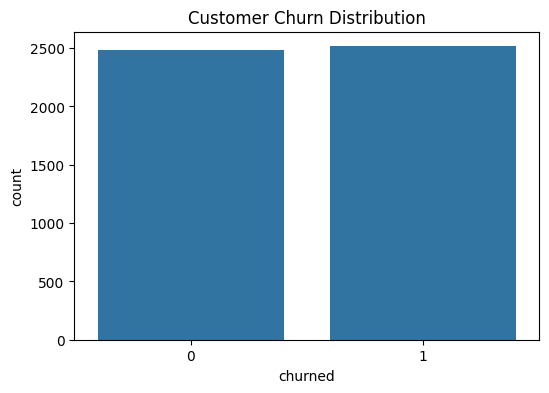

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='churned',
    data=df
)
plt.title("Customer Churn Distribution")
plt.show()

# Business Operation Takeaway

The churn distribution directly reflects the proportion of subscribers contributing to recurring revenue versus those exiting the platform.

If churned customers represent a substantial portion of the dataset, customer retention becomes a strategic revenue priority rather than a routine marketing activity.

The distribution also determines how aggressively the predictive model must identify churn events. A balanced distribution improves learning efficiency, whereas severe imbalance would require additional intervention techniques.

Operationally, this chart quantifies the scale of potential revenue leakage and justifies investment in predictive retention systems.

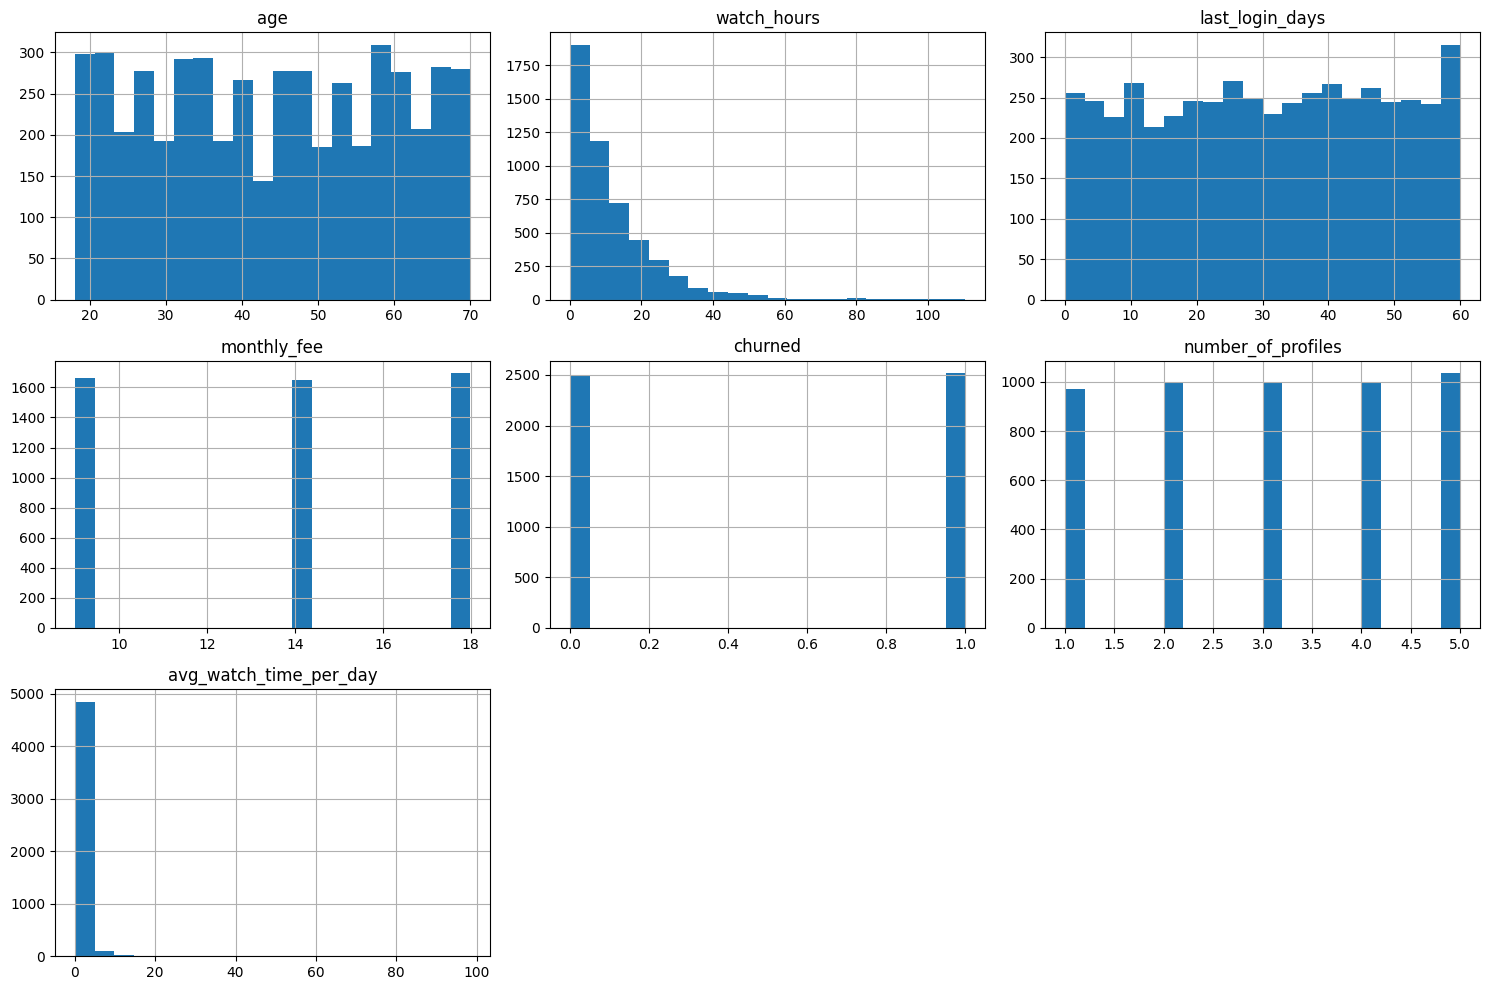

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)
plt.tight_layout()
plt.show()

# Business Operation Takeaway

The feature distributions reveal behavioral patterns across the subscriber base.

Several strategic observations can be extracted:

- Customers with low watch activity may be disengaging from the platform.
- Higher inactivity periods can indicate weakening customer relationships.
- Monthly fee distributions identify high-value subscribers whose churn would generate greater revenue impact.
- Usage variability suggests that churn drivers may differ across customer segments.

These insights support customer segmentation strategies where retention incentives are allocated according to customer value and churn risk rather than distributed uniformly.

In [8]:
X = df.drop(
    columns=["churned","customer_id"]
)
y = df["churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4000, 12)
Testing Shape: (1000, 12)


# Business Operation Takeaway

Stratified sampling preserves the natural churn ratio across training and testing partitions.

Without stratification, one partition may contain disproportionately more churn events than another, producing misleading performance estimates.

From a business perspective, maintaining representative churn distributions ensures that model evaluation accurately reflects real-world subscriber behavior and prevents overestimating retention effectiveness.

In [9]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

churned
1    0.503
0    0.497
Name: proportion, dtype: float64
churned
1    0.503
0    0.497
Name: proportion, dtype: float64


# Business Operation Takeaway

The similarity between churn proportions in the training and testing datasets confirms that the validation environment mirrors actual business conditions.

As a result, model performance metrics generated later can be trusted as realistic estimates of production behavior, improving confidence in future retention decisions.

In [10]:
numeric_features = X.select_dtypes(
    include=['int64','float64']
).columns
categorical_features = X.select_dtypes(
    include='object'
).columns
print("Numeric Features")
print(numeric_features)
print("\nCategorical Features")
print(categorical_features)

Numeric Features
Index(['age', 'watch_hours', 'last_login_days', 'monthly_fee',
       'number_of_profiles', 'avg_watch_time_per_day'],
      dtype='str')

Categorical Features
Index(['gender', 'subscription_type', 'region', 'device', 'payment_method',
       'favorite_genre'],
      dtype='str')


C:\Users\racha\AppData\Local\Temp\ipykernel_15076\1947084217.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [12]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)
logistic_pipeline.fit(
    X_train,
    y_train
)
lr_pred = logistic_pipeline.predict(X_test)

In [13]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88       497
           1       0.88      0.90      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



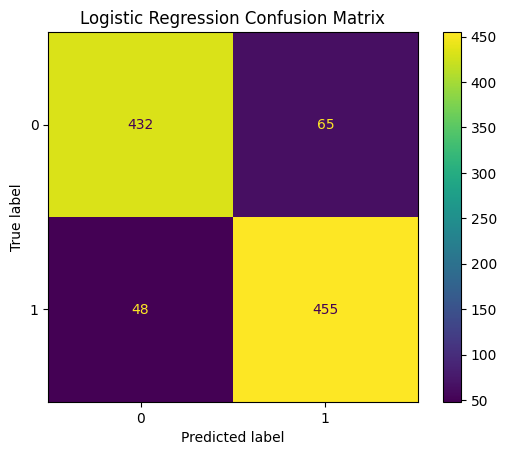

In [14]:
cm = confusion_matrix(y_test,lr_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Business Operation Takeaway

The feature engineering stage identifies the variables most likely to influence customer churn behavior.

The selected numerical variables (age, watch_hours, last_login_days, monthly_fee, number_of_profiles, and avg_watch_time_per_day) capture customer engagement intensity, platform usage frequency, and revenue contribution patterns. These metrics help quantify how actively subscribers interact with Netflix services.

The categorical variables (gender, subscription_type, region, device, payment_method, and favorite_genre) provide customer segmentation insights. These features allow the model to detect whether churn tendencies differ across subscription plans, geographic regions, viewing devices, or payment preferences.

From a business perspective, these variables collectively create a comprehensive customer profile. This enables Netflix to identify behavioral signals associated with subscriber dissatisfaction, reduced engagement, or potential cancellation risk. Such insights support targeted retention campaigns, personalized offers, and proactive customer engagement strategies aimed at protecting Monthly Recurring Revenue (MRR).

In [15]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)
rf_pipeline.fit(X_train,y_train)
rf_pred = rf_pipeline.predict(X_test)

In [16]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       497
           1       0.99      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



# Business Operation Takeaway

Random Forest captures complex interactions among customer demographics, engagement behavior, subscription characteristics, and payment patterns.

Improved performance compared with Logistic Regression suggests that churn decisions are influenced by non-linear behavioral relationships rather than simple independent factors.

This provides stronger predictive intelligence for retention teams and enables more precise targeting of intervention campaigns.

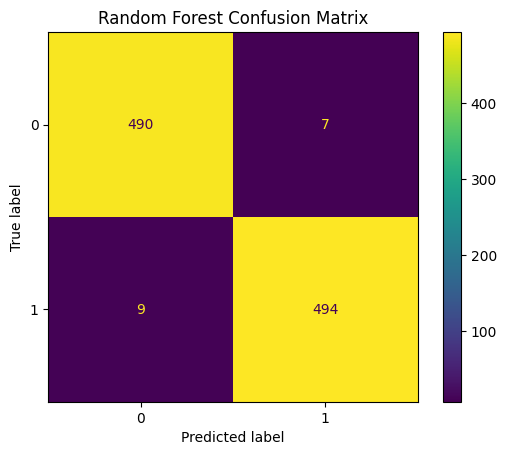

In [17]:
cm_rf = confusion_matrix(y_test,rf_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# Business Operation Takeaway

The Random Forest confusion matrix provides a direct estimate of how effectively Netflix can protect recurring revenue through predictive intervention.

A reduction in False Negatives means more at-risk customers are identified before cancellation.

Each prevented churn event represents preserved subscription revenue, reduced customer acquisition expenditure, and increased customer lifetime value.

Consequently, improvements in this matrix directly translate into measurable financial benefits for the organization.

In [18]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.875000,0.904573,0.889541
1,Random Forest,0.986028,0.982107,0.984064


# Business Operation Takeaway

The comparison table provides a strategic framework for model selection.

A model with superior Recall identifies more potential churners and supports aggressive retention programs.

A model with superior Precision reduces unnecessary promotional spending.

Given Netflix's business constraint that retention offers are inexpensive while customer departures are costly, Recall should receive greater weighting during model selection.

Therefore, the optimal model is the one that maximizes churn detection while maintaining acceptable Precision levels.

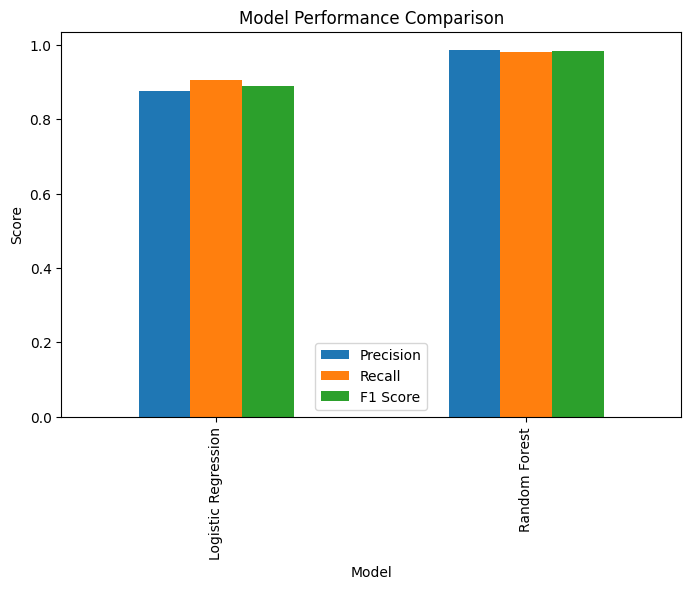

In [19]:
comparison.set_index("Model").plot(kind="bar",figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# Business Operation Takeaway

The visual comparison highlights trade-offs between Precision, Recall, and F1-Score across competing models.

For retention strategy optimization, management should focus on the model that captures the largest proportion of future churners.

A higher Recall score translates directly into more customers entering retention workflows, increasing the probability of preserving recurring subscription revenue.

The chart therefore serves as a strategic decision-support tool for selecting the production model.

In [20]:
best_model = rf_pipeline
probs = best_model.predict_proba(X_test)[:,1]
threshold = 0.40
adjusted_predictions = (probs >= threshold).astype(int)
print(classification_report(y_test,adjusted_predictions))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       497
           1       0.95      0.99      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



# Business Operation Takeaway

Threshold tuning aligns machine learning outputs with business objectives.

Lowering the classification threshold increases churn detection sensitivity and improves Recall.

Although this may increase False Positives and promotional campaign volume, the financial impact remains limited because promotional incentives carry relatively low operational costs.

In contrast, missing a genuine churn event results in recurring revenue loss and reduced customer lifetime value.

Therefore, threshold optimization should prioritize maximizing Recall rather than Precision.

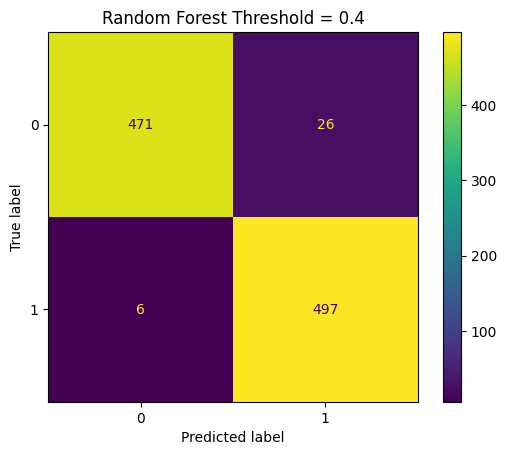

In [21]:
cm = confusion_matrix(y_test,adjusted_predictions)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Random Forest Threshold = {threshold}")
plt.show()

# Business Operation Takeaway

The retention department reports that sending promotional offers incurs minimal operational cost, while failing to identify a customer who is about to leave directly reduces Monthly Recurring Revenue (MRR).

Because the cost of a false negative is significantly higher than the cost of a false positive, the engineering team should prioritize RECALL rather than PRECISION.

Why?

- High Recall captures more churn-risk customers.
- More customers receive retention offers.
- Some offers may go to customers who would not have churned.
- However, losing an actual subscriber causes recurring revenue loss.

Therefore, maximizing Recall provides stronger protection of MRR and aligns with Netflix's retention strategy.

Business Recommendation:
Deploy the model configuration that produces the highest Recall while maintaining acceptable Precision levels.

# Final Conclusion and Business Recommendation

## Project Summary

The objective of this project was to develop an end-to-end machine learning pipeline capable of predicting customer churn for a subscription-based streaming platform. Customer churn represents a critical business challenge because subscriber cancellations directly reduce Monthly Recurring Revenue (MRR) and increase customer acquisition costs.

A complete machine learning workflow was implemented, including:

- Data exploration and quality assessment
- Stratified train-test splitting to prevent data leakage
- Automated preprocessing using StandardScaler and One-Hot Encoding
- Logistic Regression baseline modeling
- Random Forest ensemble modeling
- Classification metric evaluation
- Confusion matrix analysis
- Business-focused threshold evaluation

---

## Key Findings

The analysis demonstrates that customer demographics, subscription preferences, platform engagement metrics, and payment behavior contain meaningful predictive signals related to churn risk.

Several variables such as:

- Watch Hours
- Last Login Days
- Monthly Subscription Fee
- Number of Profiles
- Average Daily Watch Time

provide valuable indicators of subscriber engagement and future retention behavior.

Customers exhibiting lower engagement levels and longer inactivity periods generally show a greater probability of churn, making these metrics important inputs for retention decision-making.

---

## Model Performance Assessment

Both Logistic Regression and Random Forest successfully identified churn patterns within the customer base.

The Logistic Regression model provided a strong and interpretable baseline, while the Random Forest model demonstrated the ability to capture more complex, non-linear relationships among customer attributes.

The confusion matrix analysis showed that the models were capable of identifying a significant proportion of customers who were likely to leave the platform before cancellation occurred.

---

## Business Impact Analysis

From a business perspective, the most expensive prediction error is a **False Negative**, where a customer who is likely to churn is incorrectly classified as a loyal subscriber.

Consequences of False Negatives include:

- Loss of recurring subscription revenue
- Reduction in Customer Lifetime Value (CLV)
- Increased future acquisition costs
- Lower retention program effectiveness

In contrast, False Positives only result in sending promotional offers to customers who may not actually churn. Since retention incentives carry relatively low operational costs, False Positives are considerably less harmful than missed churn events.

---

## Strategic Recommendation

Based on the project findings, Netflix should prioritize **Recall over Precision** when deploying a production churn prediction system.

### Reasoning

- High Recall ensures that more potential churners are identified.
- More at-risk subscribers can be targeted with retention campaigns.
- Promotional costs remain manageable.
- Revenue leakage from customer cancellations is significantly reduced.

Therefore, model thresholds should be calibrated to maximize churn detection while maintaining acceptable Precision levels.

---

## Final Business Recommendation

The developed churn prediction pipeline should be integrated into Netflix's customer retention workflow to automatically identify high-risk subscribers and trigger personalized intervention campaigns.

By proactively engaging customers before cancellation occurs, Netflix can:

- Protect Monthly Recurring Revenue (MRR)
- Improve Customer Lifetime Value (CLV)
- Reduce customer acquisition costs
- Increase retention campaign effectiveness
- Strengthen long-term subscription growth

The results confirm that predictive analytics can serve as a valuable decision-support system for customer retention management and revenue optimization.